# Exercise 01: Exploring and Analyzing Protein Structures in the PDB Database

## Learning Objectives

In this exercise, you will learn to:
- Query the PDB database programmatically
- Extract and analyze structural quality metrics
- **Critically evaluate** data quality and make informed decisions
- **Interpret** structural data in biological context
- Use a multiple sequence alignment to find conserved regions and relate them to structure

## Using AI Tools

You may use AI assistants (ChatGPT, Claude, etc.) for:
- Understanding syntax and library functions
- Debugging code errors
- Generating code snippets

However, **you must demonstrate**:
- Your own biological reasoning and interpretation
- Justification for decisions (not just "AI said so")
- Critical evaluation of results

**The exercise assesses your understanding and judgment, not code generation.**

**Time budget: about 45 minutes** for this guide, read and run. The workbook that follows
is roughly another 45 to 60 minutes on your own protein.

## What you will not learn here

- How to **predict** a structure. That is Day 2 and ex02.
- How to **simulate** one. Day 3 and ex03.
- How to **dock** a ligand into one. Day 4 and ex04.
- Crystallographic refinement itself. You will read quality metrics, not produce them.

**Exercise 01 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex01_guide.ipynb`** (this one) | A fully worked walkthrough on one protein, 1FSZ. Every cell is filled in and explained. Nothing here is graded — read it, run it, and use it as your reference. |
| **`ex01_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

## Introduction and Basic Skills

We'll start by learning how to query PDB and extract structural information, using one
real protein — FtsZ, PDB entry **1FSZ** — end to end.

In [1]:
# Check if running on Google Colab
try:
    from google.colab import drive
    is_google_colab = True
except ImportError:
    is_google_colab = False

# If on Google Colab, install the package
if is_google_colab:
    %pip install numpy==2.1.3 scipy==1.16.3 pandas==2.2.3 biopandas==0.4.1 pypdb==2.4 tqdm==4.67.3 py3dmol==2.4.0 biopython==1.85 pyfamsa==0.7.0

# NOTE: Ignore specific warning message from ipykernel=5.5.6
import warnings
import os


In [2]:
# Import libraries
import io
import math
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypdb
from biopandas.pdb import PandasPdb
from Bio import SeqIO
from pyfamsa import Aligner, Sequence
import py3Dmol
from tqdm import tqdm


# Suppress all warnings at the Python level
warnings.filterwarnings('ignore')

# Also set environment variable to suppress warnings
os.environ['PYTHONWARNINGS'] = 'ignore'

# pandas draws through matplotlib by default -- df.plot() gives us a real Axes back,
# which keeps most plots in this notebook to two or three lines.
print("All libraries loaded successfully")

All libraries loaded successfully


/tmp/claude-1000/-home-yerko-Development-structural-bioinformatics-lectures/92aff5a2-20a3-4863-bcd9-98a4d4a8d4fb/scratchpad/ex01env/lib/python3.13/site-packages/biopandas/pdb/pandas_pdb.py:27: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  pd_version = LooseVersion(pd.__version__)


### Meet FtsZ, and our anchor structure: 1FSZ

**FtsZ** drives bacterial and archaeal cell division: it self-assembles into a contractile
ring at the division site and constricts to split the cell. It is a GTPase and a structural
homolog of eukaryotic **tubulin**, which makes it an attractive antibacterial target.

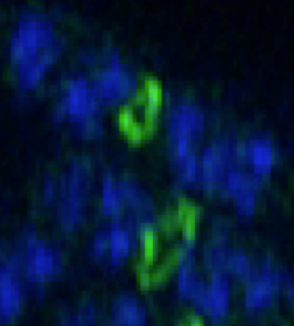

*Z-rings caught in the act. Super-resolution fluorescence of two E. coli cells at
different stages of constriction, with FtsZ in green marking the division plane.*

<sub>Figure: [Zrings.png](https://en.wikipedia.org/wiki/FtsZ#/media/File:Zrings.png) by Hazelsplace, Wikimedia Commons, [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). Unmodified.</sub>

Everything below is anchored on **1FSZ**, FtsZ from the archaeon *Methanocaldococcus
jannaschii*. Why this one:

- **Two clear domains** in a 372-residue construct: an N-terminal GTPase core (roughly
  23-190) and a C-terminal domain (roughly 190-356). Good for domain-level thinking.
- **Bound GDP** resolved in the crystal. FtsZ is a GTPase and this is its real nucleotide,
  not a crystallization artifact.
- The crystal resolved only residues **23-356**. The 38 residues at the two ends were never
  modeled, and there are no internal gaps. Keep that number for the B-factor section.


### The PDB, and why programmatic access matters

You met the PDB in the lectures. What matters here is the **access pattern**.

You cannot click through 250 entries one at a time and keep the comparison consistent. The
Search API lets you send one JSON query over HTTP and get every matching structure back as
structured JSON, ready to filter, sort and tabulate. The shape is always **submit a query,
get JSON back, parse it in code**, and you will meet it again later in this notebook for a
sequence-alignment service. It is how you talk to any large database, not a PDB trick.

We use `requests` directly and `pypdb`, a thin wrapper over the same API. Later,
**BioPandas** loads one structure's coordinates into a DataFrame.

[PDB Search API docs](https://search.rcsb.org/index.html#search-api) ·
[worked examples](https://search.rcsb.org/index.html#examples)


### 1. Programmatic query: start from 1FSZ's sequence and find the FtsZ family

Rather than searching with an arbitrary keyword or an off-species identifier, we start from
**1FSZ's own sequence** and ask the PDB: "what else in here looks like this?"

Three helpers do all the talking to the PDB in this notebook, and they are the same three
you will need for any other protein. Everything later in the guide calls them rather than
repeating their contents.

| Helper | Gives you |
|---|---|
| `fetch_sequence(pdb_id)` | the entry's sequence, as a plain string |
| `search_pdb(value, by=...)` | PDB IDs matching a sequence, or a free-text term |
| `extract_structure_info(pdb_id)` | method, year, resolution, R-work, R-free |


In [3]:
def fetch_sequence(pdb_id):
    """The entry's sequence, as a plain string."""
    fasta = requests.get(f"https://www.rcsb.org/fasta/entry/{pdb_id}").text
    return str(next(SeqIO.parse(io.StringIO(fasta), "fasta")).seq)


def search_pdb(value, by="sequence", identity_cutoff=0.3, rows=100):
    """PDB IDs matching a sequence (default) or a free-text term such as a UniProt ID.

    Results come back ranked, best match first.
    """
    if by == "sequence":
        query = {"type": "terminal", "service": "sequence",
                 "parameters": {"evalue_cutoff": 1, "identity_cutoff": identity_cutoff,
                                "target": "pdb_protein_sequence", "value": value}}
    else:
        query = {"type": "terminal", "service": "full_text", "parameters": {"value": value}}

    response = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query",
        json={"query": query, "return_type": "entry",
              "request_options": {"paginate": {"start": 0, "rows": rows},
                                  "sort": [{"sort_by": "score", "direction": "desc"}]}},
    )
    response.raise_for_status()
    return [hit["identifier"] for hit in response.json().get("result_set", [])]


def extract_structure_info(pdb_id):
    """Method, year and quality metrics for one entry. None if the entry cannot be read.

    Not every method reports a resolution: NMR entries have no `refine` block at all, so
    those fields come back as None rather than raising.
    """
    try:
        info = pypdb.get_info(pdb_id)
    except Exception as exc:
        print(f"Skipping {pdb_id}: {exc}")
        return None

    refine = (info.get("refine") or [{}])[0]
    return {
        "pdb_id": pdb_id,
        "method": info["exptl"][0]["method"],
        "year": info["rcsb_accession_info"]["deposit_date"][:4],
        "resolution": refine.get("ls_d_res_high"),
        "r_work": refine.get("ls_R_factor_R_work"),
        "r_free": refine.get("ls_R_factor_R_free"),
    }


In [4]:
# Everything downstream is built from these three calls.
anchor_sequence = fetch_sequence("1FSZ")
pdb_ids = search_pdb(anchor_sequence)
print(f"1FSZ sequence: {len(anchor_sequence)} residues")
print(f"Related entries found: {len(pdb_ids)}; first hit is {pdb_ids[0]} (1FSZ matches itself)")

rows = [extract_structure_info(pdb_id) for pdb_id in tqdm(pdb_ids[:20], desc="Fetching")]
df = pd.DataFrame([r for r in rows if r])
print(f"\nBuilt a table of {len(df)} structures")
df.head()


1FSZ sequence: 372 residues
Related entries found: 100; first hit is 1FSZ (1FSZ matches itself)


Fetching: 100%|██████████| 20/20 [00:06<00:00,  2.92it/s]



Built a table of 20 structures


,pdb_id,method,year,resolution,r_work,r_free
0,1FSZ,X-RAY DIFFRACTION,1997,2.8,0.199,0.282
1,1W58,X-RAY DIFFRACTION,2004,2.5,0.221,0.253
2,1W59,X-RAY DIFFRACTION,2004,2.7,0.216,0.296
3,1W5A,X-RAY DIFFRACTION,2004,2.4,0.218,0.264
4,1W5B,X-RAY DIFFRACTION,2004,2.2,0.209,0.259


### Basic analysis and summary statistics

In [5]:
# Summary statistics
print("=== Dataset Summary ===")
print(f"Total structures: {len(df)}")
print(f"\nBy experimental method:")
print(df["method"].value_counts())

# Resolution statistics (X-ray only)
xray_df = df[df["method"] == "X-RAY DIFFRACTION"]
resolutions = xray_df["resolution"].dropna()
if len(resolutions) > 0:
    print(
        f"\nX-ray resolution range: {resolutions.min():.2f} - {resolutions.max():.2f} Å"
    )
    print(f"Mean resolution: {resolutions.mean():.2f} Å")


=== Dataset Summary ===
Total structures: 20

By experimental method:
method
X-RAY DIFFRACTION      19
ELECTRON MICROSCOPY     1
Name: count, dtype: int64

X-ray resolution range: 1.43 - 3.19 Å
Mean resolution: 2.30 Å


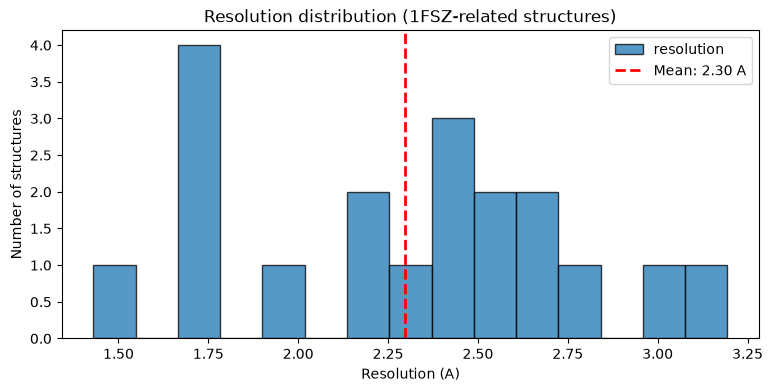

n = 19   mean 2.30 A   best 1.43 A   worst 3.19 A


In [6]:
# Resolution distribution, straight off the DataFrame.
xray = df.loc[df["method"] == "X-RAY DIFFRACTION", "resolution"].dropna()

if len(xray):
    ax = xray.plot.hist(
        bins=15, edgecolor="black", alpha=0.75, figsize=(9, 4),
        title="Resolution distribution (1FSZ-related structures)",
    )
    ax.axvline(xray.mean(), color="red", ls="--", lw=2,
               label=f"Mean: {xray.mean():.2f} A")
    ax.set_xlabel("Resolution (A)")
    ax.set_ylabel("Number of structures")
    ax.legend()
    plt.show()

    print(f"n = {len(xray)}   mean {xray.mean():.2f} A   "
          f"best {xray.min():.2f} A   worst {xray.max():.2f} A")
else:
    print("No X-ray structures with a resolution in this sample.")

### 2. Visualization with py3Dmol

### The structure helpers

Five more functions, and the same rule as before: defined once here, called everywhere
below. These are the ones you will need again on your own protein.

| Helper | Gives you |
|---|---|
| `load_structure(pdb_id)` | protein atoms and heteroatoms, as two DataFrames |
| `heteroatom_inventory(hetatms)` | every non-protein species, with atom and copy counts |
| `contacts_within(atoms, hetatms, resname, radius)` | residues near a ligand |
| `bfactor_profile(atoms)` | CA B-factors indexed by residue, gaps included |
| `show_structure(pdb_id, ...)` | a py3Dmol cartoon, optionally highlighting residues |


In [7]:
from scipy.spatial import cKDTree


def load_structure(pdb_id):
    """Protein atoms and heteroatoms for one entry, as two DataFrames."""
    ppdb = PandasPdb().fetch_pdb(pdb_id)
    return ppdb.df["ATOM"], ppdb.df["HETATM"]


def heteroatom_inventory(hetatms):
    """Every non-protein species in the file, with how many atoms and copies each has."""
    return (
        hetatms.groupby("residue_name")
        .agg(atoms=("atom_number", "size"), copies=("residue_number", "nunique"))
        .sort_values("atoms", ascending=False)
    )


def contacts_within(atoms, hetatms, resname, radius=4.0):
    """Residues with any atom within `radius` angstroms of the named heteroatom."""
    ligand = hetatms.loc[hetatms["residue_name"] == resname,
                         ["x_coord", "y_coord", "z_coord"]].values
    if not len(ligand):
        return atoms.iloc[0:0][["residue_number", "residue_name"]]
    tree = cKDTree(atoms[["x_coord", "y_coord", "z_coord"]].values)
    near = sorted({i for hit in tree.query_ball_point(ligand, r=radius) for i in hit})
    return (atoms.iloc[near][["residue_number", "residue_name"]]
            .drop_duplicates().sort_values("residue_number"))


def bfactor_profile(atoms):
    """CA B-factors indexed by residue number, with NaN wherever the crystal resolved
    nothing. Reindexing onto the full range is what makes matplotlib draw real gaps."""
    ca = atoms[atoms["atom_name"] == "CA"]
    profile = (ca.set_index("residue_number")["b_factor"]
               .reindex(range(ca["residue_number"].min(), ca["residue_number"].max() + 1)))
    profile.index.name = "Residue number"
    return profile


def show_structure(pdb_id, highlight=(), ligand=None, width=800, height=500):
    """Cartoon view of an entry. `highlight` colours residues red, `ligand` shows a
    heteroatom as sticks."""
    view = py3Dmol.view(query=f"pdb:{pdb_id}", width=width, height=height)
    view.setStyle({"cartoon": {"color": "lightgrey" if len(highlight) else "spectrum"}})
    if len(highlight):
        view.addStyle({"resi": list(highlight)}, {"cartoon": {"color": "red"}})
        view.addStyle({"resi": list(highlight)}, {"stick": {"color": "red"}})
    if ligand:
        view.addStyle({"resn": ligand}, {"stick": {"colorscheme": "greenCarbon"}})
    view.zoomTo()
    return view


In [8]:
# Visualize the best-resolution X-ray structure in our sample
best_structure = df[df["method"] == "X-RAY DIFFRACTION"].nsmallest(1, "resolution").iloc[0]
print(f"Visualizing: {best_structure['pdb_id']} ({best_structure['resolution']:.2f} Å)")
show_structure(best_structure["pdb_id"]).show()


Visualizing: 4M8I (1.43 Å)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Structure analysis with BioPandas

Now let's zoom in on our anchor structure, 1FSZ itself, for a deeper analysis. We'll use
BioPandas to load its atomic coordinates into a pandas DataFrame.

In [9]:
pdb_id = "1FSZ"
atoms_df, hetatms = load_structure(pdb_id)
print(f"{pdb_id}: {len(atoms_df)} protein atoms, "
      f"{atoms_df['residue_number'].nunique()} residues, {len(hetatms)} heteroatoms")
atoms_df.head()


1FSZ: 2479 protein atoms, 334 residues, 144 heteroatoms


,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,x_coord,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx
0,ATOM,1,,N,,SER,,A,23,,...,18.623,-11.552,-5.579,1.0,74.80,,,N,NaN,497
1,ATOM,2,,CA,,SER,,A,23,,...,17.707,-10.891,-4.602,1.0,70.57,,,C,NaN,498
2,ATOM,3,,C,,SER,,A,23,,...,17.275,-9.526,-5.088,1.0,70.22,,,C,NaN,499
3,ATOM,4,,O,,SER,,A,23,,...,18.004,-8.861,-5.812,1.0,71.08,,,O,NaN,500
4,ATOM,5,,CB,,SER,,A,23,,...,18.399,-10.704,-3.259,1.0,71.24,,,C,NaN,501


### What else is in the crystal? Cataloguing the heteroatoms

A PDB entry is not just a protein. Everything that was in the crystal and could be
modelled into the density is in the file, recorded as `HETATM` rather than `ATOM`:
substrates, cofactors, metal ions, and — very often — molecules that have nothing to do
with the biology at all.

**This distinction is one of the most consequential things to get right about a
structure**, and it is easy to get wrong. Buffer components (HEPES, acetate), solvents
(glycerol, ethanol), cryoprotectants and crystallisation additives all appear in exactly
the same way as a real substrate. Nothing in the file marks which is which. A study that
docks against a cryoprotectant, or "discovers" a binding site that is really a buffer
molecule wedged in a surface cleft, is a study built on a misread `HETATM` record.

So before doing anything else with a structure, list what is actually in it.

In [10]:
inventory = heteroatom_inventory(hetatms)
print(f"Heteroatom species in {pdb_id}:\n")
print(inventory.to_string())


Heteroatom species in 1FSZ:

              atoms  copies
residue_name               
HOH             116     116
GDP              28       1


**The whole of 1FSZ, classified:**

| Code | Atoms | What it is | Real, or experimental artifact? |
|---|---|---|---|
| `GDP` | 28, one copy | guanosine 5'-diphosphate | **the biological ligand.** FtsZ is a GTPase and this is its real nucleotide |
| `HOH` | 116 | water | **solvent.** Never the answer to "what does this protein bind" |

**How you know, without being told.** No single rule settles it. Applied to this GDP:

- **Look it up.** The RCSB entry names the ligand and the paper says what was studied. The
  reliable route; the rest are heuristics.
- **Where does it sit?** Computed above: 17 residues within 4 Å, including the glycine-rich
  `GLY130-GLY136`. That many specific contacts is not an accident. A cryoprotectant in a
  surface groove looks nothing like it.
- **Is it a lab reagent?** Glycerol, HEPES, MES, PEG, sulfate, acetate and DMSO come from
  the experiment. A guanine nucleotide does not.
- **Does it recur in relatives?** Guanine nucleotides appear across the FtsZ and tubulin
  family. A cofactor recurs; a cryoprotectant is one crystallisation's accident.
- **Occupancy and order.** One full, well-ordered copy. Partial occupancy and high
  B-factors point the other way.

**A clean entry does not make the question optional, only easy.** Many carry five or six
species where one is the biology and nothing marks which.


In [11]:
contacts = contacts_within(atoms_df, hetatms, "GDP", radius=4.0)
print(f"Residues within 4 A of GDP: {len(contacts)}\n")
print(", ".join(f"{r.residue_name}{r.residue_number}" for r in contacts.itertuples()))


Residues within 4 A of GDP: 17

GLY46, GLY47, ALA48, ASN51, GLY130, LEU131, GLY133, GLY134, THR135, GLY136, PRO161, GLU165, ARG169, PHE208, ALA211, ASP212, LEU215


That contact list is the **binding site**, derived from geometry rather than assumed. Keep
it: a real ligand sits in a pocket lined by many residues making specific contacts, and
you can now say concretely which ones. It is also the list to compare against the
conserved positions you compute further down — if evolution has conserved the residues
that touch the nucleotide, that is a strong, checkable signal that the site matters.

### 3. B-factor analysis: predict first, then plot

B-factors (temperature factors) indicate atomic mobility and flexibility in protein
structures. Let's analyze B-factor patterns to understand protein dynamics and identify
flexible regions.

**How you'd reason about this before plotting (a worked example of predict-first):**

1FSZ has an N-terminal GTPase domain (roughly residues 23-190, the tubulin-homolog
catalytic core) and a C-terminal domain (roughly residues 190-356). Before looking at any
numbers, the biologically motivated prediction is: the catalytic GTPase domain does the
core, conserved, GTP-binding/hydrolysis job — that kind of functional core is usually
**more rigid** (lower B-factor) than a more peripheral domain, which has more freedom to
move without breaking the protein's central function.

This is exactly the kind of prediction you should write down **before** running the plot
below, on your own protein, in the workbook — being wrong is fine, the point is
to have a falsifiable guess on record before you see the answer.

Residue range: 23 to 356
Present: 334   Missing: 0

B-factor: mean 50.6, min 19.0, max 99.8 A^2


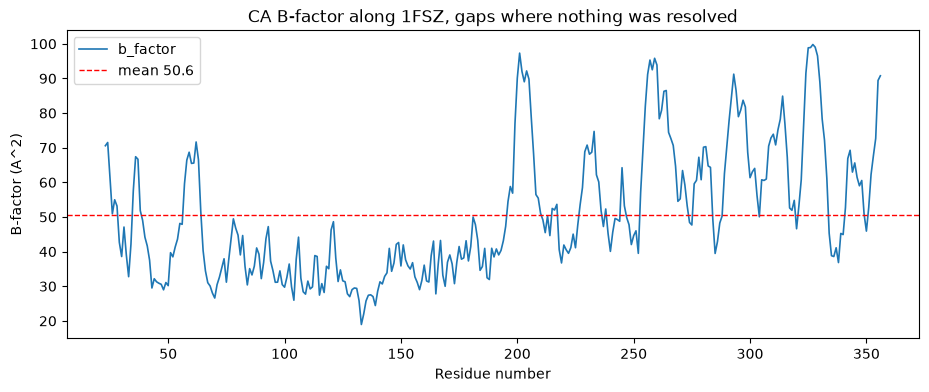

In [12]:
bfactors = bfactor_profile(atoms_df)
print(f"Residue range: {bfactors.index.min()} to {bfactors.index.max()}")
print(f"Present: {bfactors.notna().sum()}   Missing: {bfactors.isna().sum()}")
print(f"\nB-factor: mean {bfactors.mean():.1f}, min {bfactors.min():.1f}, "
      f"max {bfactors.max():.1f} A^2")

ax = bfactors.plot(figsize=(11, 4), lw=1.2,
                   title=f"CA B-factor along {pdb_id}, gaps where nothing was resolved")
ax.set_ylabel("B-factor (A^2)")
ax.axhline(bfactors.mean(), color="red", ls="--", lw=1, label=f"mean {bfactors.mean():.1f}")
ax.legend()
plt.show()


**What this confirms:** the GTPase domain (~38 Ų mean) is indeed noticeably more
rigid than the C-terminal domain (~63 Ų mean) — the prediction above holds. Note also
that this plot has **zero internal gaps**: the 38 unresolved residues (22 N-terminal, 16
C-terminal) don't show up as a break *inside* this range, because they're entirely outside
it (residue numbers 1-22 and 357-372 simply never appear in `ca_atoms` at all). You only
notice they're missing by checking the modeled count (334) against the full construct
(372) — a gap worth remembering when we come to structure prediction.

---

## Final code: classifying structural quality across the 1FSZ family

A common real task: given many structures of the same protein, which one should you
use? Below is a small, **correct, final** function for that — no bugs to find, this is
what a working version of "find the best structure" looks like — followed by a worked
walkthrough applying it to the real 1FSZ-rooted dataset from above.

This is not a fill-in-the-blank exercise: everything below is filled in and explained.

In [13]:
# Resolution is in angstroms, so the best structure has the MINIMUM value, not the
# maximum. Entries with no resolution at all (NMR, for instance) are skipped rather
# than crashing the batch.
def find_best_structure(value, by="sequence"):
    """Highest-resolution experimental structure among a protein's PDB relatives.

    Composes the three helpers above, so it works for any sequence or UniProt ID.
    Returns None, with a message, rather than a wrong answer, if nothing usable is found.
    """
    candidates = search_pdb(value, by=by)
    if not candidates:
        print("No candidate structures found for this query.")
        return None

    scored = []
    for pdb_id in tqdm(candidates, desc="Checking resolutions"):
        row = extract_structure_info(pdb_id)
        if row and row["resolution"] is not None:
            scored.append((row["resolution"], row["pdb_id"]))

    if not scored:
        print("No candidate structure reported a usable resolution value.")
        return None

    best_resolution, best_pdb = min(scored)
    return best_pdb, best_resolution


In [14]:
# Apply it to our real 1FSZ-rooted dataset
best_pdb, best_res = find_best_structure(anchor_sequence)
print(f"Best-resolution structure in the 1FSZ family: {best_pdb} ({best_res:.2f} Å)")


Checking resolutions: 100%|██████████| 100/100 [00:33<00:00,  3.01it/s]


Best-resolution structure in the 1FSZ family: 6RVQ (1.14 Å)


### 4. Structural-quality classification, built on real data

Instead of a made-up table, let's classify the real structures already sitting in `df`
(the 20 structures batch-processed earlier) using simple, defensible resolution tiers.

In [15]:
def classify_quality(row):
    if row["method"] != "X-RAY DIFFRACTION" or pd.isna(row["resolution"]):
        return "no resolution metric (use ensemble spread / local confidence instead)"
    if row["resolution"] < 2.0:
        return "excellent (< 2.0 Å) -- good for drug design / precise side-chain geometry"
    if row["resolution"] < 3.0:
        return "good (2.0-3.0 Å) -- reliable backbone, side-chain placement less certain"
    return "moderate (> 3.0 Å) -- backbone topology only, don't trust fine detail"


df["quality_tier"] = df.apply(classify_quality, axis=1)
df[["pdb_id", "method", "resolution", "r_free", "quality_tier"]].sort_values(
    "resolution", na_position="last"
)


,pdb_id,method,resolution,r_free,quality_tier
16,4M8I,X-RAY DIFFRACTION,1.430,0.20616,excellent (< 2.0 Å) -- good for drug design / ...
5,2VAP,X-RAY DIFFRACTION,1.700,0.20900,excellent (< 2.0 Å) -- good for drug design / ...
13,2VXY,X-RAY DIFFRACTION,1.700,0.21800,excellent (< 2.0 Å) -- good for drug design / ...
19,3VOA,X-RAY DIFFRACTION,1.730,0.22990,excellent (< 2.0 Å) -- good for drug design / ...
9,2RHJ,X-RAY DIFFRACTION,1.761,0.20800,excellent (< 2.0 Å) -- good for drug design / ...
8,2RHH,X-RAY DIFFRACTION,2.001,0.25700,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
15,3WGJ,X-RAY DIFFRACTION,2.179,0.23520,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
4,1W5B,X-RAY DIFFRACTION,2.200,0.25900,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
17,3VO8,X-RAY DIFFRACTION,2.255,0.23700,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."
3,1W5A,X-RAY DIFFRACTION,2.400,0.26400,"good (2.0-3.0 Å) -- reliable backbone, side-ch..."


### 5. Critical evaluation: which structure for which purpose?

**Scenario:** you're planning a drug-design project on the FtsZ family, and separately
you want to study its flexibility. Which structure(s) from the table above would you
pick for each, and why?

**A worked answer (a model of the reasoning, not a template to copy verbatim for your own
protein):**
- **For drug design**, pick the structure `find_best_structure` returned above
  (`best_pdb`, at `best_res` Å) — the tightest resolution means the most precise
  side-chain and pocket geometry, which matters directly for docking or structure-based
  design. R-free (not just resolution) is worth checking too: a low resolution number
  with a high R-free means the model doesn't actually explain the diffraction data well,
  despite looking sharp on paper.
- **For studying flexibility**, resolution is a much weaker signal than the B-factor
  section above already showed — even a single well-resolved structure like 1FSZ itself
  gives you a real per-residue flexibility profile via its B-factors, and cross-checking
  against **several** structures of the same protein (do they agree on which regions are
  most mobile?) is more informative than picking the "best" single one by resolution
  alone.
- **The general lesson:** "best resolution" and "best structure for this specific
  question" are not always the same structure — the quality tiers above are a starting
  filter, not a final verdict, and the same limitations-vs-purpose reasoning applies
  whatever protein you're working with.

---

## 6. Multiple sequence alignment: where is FtsZ conserved?

So far we've asked "how good is this structure?" Now let's ask a different question:
"which *parts* of the structure does evolution care most about?" A **multiple sequence
alignment (MSA)** across several FtsZ relatives lets us find columns that stayed
identical across large evolutionary distances — a strong signal that a residue matters
functionally, independent of any single structure's quality.

We align **in process**, with FAMSA through the `pyfamsa` package: no external binary, no
job queue, no waiting. That matters for a class of thirty people hitting the same service
at the same time.

**Choosing which sequences to align (a rule that has to work for any protein, not just
1FSZ):** aligning all ~250 hits would be slow to run and hard to read; aligning too few
makes "conserved" nearly meaningless (with only 2-3 sequences, almost everything looks
conserved by chance). We use a simple, generic rule: take up to **10** sequences, spread
evenly across the *ranked* hit list (from the closest match to the more distant ones,
not just the top 10 nearly-identical entries) so the alignment spans a real range of
evolutionary distance. If fewer than 3 hits exist at all (possible for an obscure
protein in the workbook), we skip the MSA rather than run a meaningless
alignment on 1-2 sequences.

In [16]:
def select_spread(ids, n_max=10, n_min=3):
    """Up to n_max entries spread evenly across a ranked list, not just the top n.

    Aligning the ten nearest matches makes everything look conserved; spreading the
    selection across the ranking buys real evolutionary distance.
    """
    if len(ids) < n_min:
        print(f"Only {len(ids)} related structure(s): too few to align (need {n_min}).")
        return []
    n = min(n_max, len(ids))
    picks = sorted({round(i * (len(ids) - 1) / (n - 1)) for i in range(n)})
    return [ids[i] for i in picks]


def align_entries(pdb_ids):
    """Fetch each entry's sequence and align them all. Returns {entry_id: aligned seq}."""
    seqs = []
    for entry_id in pdb_ids:
        fasta = requests.get(f"https://www.rcsb.org/fasta/entry/{entry_id}").text
        record = next(SeqIO.parse(io.StringIO(fasta), "fasta"))
        seqs.append(Sequence(record.id.split("|")[0].encode(), str(record.seq).encode()))
    msa = Aligner(guide_tree="upgma").align(seqs)
    return {record.id.decode(): record.sequence.decode() for record in msa}


def conservation(aligned, anchor_id, threshold=0.9):
    """Positions where >= `threshold` of sequences share the anchor's residue.

    Returns (residue_number, amino_acid, fraction), numbered on the anchor sequence:
    columns that are a gap in the anchor have no residue to report.
    """
    anchor = aligned[anchor_id]
    seqs = list(aligned.values())
    out, residue_number = [], 1
    for col, char in enumerate(anchor):
        if char == "-":
            continue
        fraction = sum(1 for s in seqs if s[col] == char) / len(seqs)
        if fraction >= threshold:
            out.append((residue_number, char, fraction))
        residue_number += 1
    return out


In [17]:
msa_subset_ids = select_spread(pdb_ids, n_max=10)
print(f"Selected {len(msa_subset_ids)} sequences: {msa_subset_ids}")


Selected 10 sequences: ['1FSZ', '2RHO', '3WGN', '6RVM', '7OHN', '5H5H', '14UJ', '14UU', '14VF', '14VQ']


In [18]:
aligned = align_entries(msa_subset_ids)
print(f"Aligned {len(aligned)} sequences into {len(next(iter(aligned.values())))} columns")


Aligned 10 sequences into 428 columns


**🔭 Optional, low-stakes:** everything above finds homologs *already in the PDB* via
a structure-sequence search. If you wanted to search much further — the wider tubulin
superfamily, or sequences that have never been crystallized at all — the tool for that is
**PSI-BLAST** (also available as an EBI REST service), which iteratively searches large
sequence databases like UniProt/NR rather than just the PDB. It is not used here: it is
slower and its runtime is far less predictable than the structure-sequence search above,
which makes it a poor fit for a live class exercise. Worth knowing it exists for your own
later work, not required here.

In [19]:
CONSERVATION_THRESHOLD = 0.9
conserved_residues = conservation(aligned, "1FSZ_1", CONSERVATION_THRESHOLD)

print(f"Alignment: {len(aligned)} sequences, {len(aligned['1FSZ_1'])} columns")
print(f"Conserved positions (>= {CONSERVATION_THRESHOLD:.0%}): {len(conserved_residues)}")

# Only positions inside 1FSZ's modelled range (23-356) have coordinates to show.
visualizable_conserved = [r for r in conserved_residues if 23 <= r[0] <= 356]
print(f"Of those, {len(visualizable_conserved)} fall in the modelled range and can be drawn.")


Alignment: 10 sequences, 428 columns
Conserved positions (>= 90%): 121
Of those, 121 fall in the modelled range and can be drawn.


In [20]:
show_structure("1FSZ",
               highlight=[r[0] for r in visualizable_conserved],
               ligand="GDP").show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Interpretation:** does conservation cluster near the bound GDP (green above), or is it
spread evenly across the structure?

**You can answer this precisely rather than by eye.** Intersect the 17 residues within 4 Å
of GDP, which you listed earlier, with your conserved positions and count the overlap. **Do
not stop at the raw count**, because on its own it proves nothing.

In the run above, 121 of 1FSZ's 334 modelled residues came out conserved: **36.2% of the
protein**. Seventeen residues picked at random would therefore give roughly **6** "conserved"
by chance alone. The observed overlap is **15 of 17**. An overlap of 6 would be nothing; 15
is the nucleotide site showing up in the evolutionary signal.

**Always compare an observed overlap against the rate you would get by chance.** Compute
both and report them together:

```python
baseline = len(conserved_residues) / n_modelled_residues   # ~0.36 here
expected = baseline * len(contact_residues)                # ~6
observed = len(set(contact_resids) & set(conserved_resids))
```

Then look at **which** residues they are. `GLY130-GLY136` is a glycine-rich stretch
(`GGxGTG`), the nucleotide-binding signature of the tubulin/FtsZ family and the structural
equivalent of the P-loop in other GTPases. Glycine there is not incidental: it lets the
backbone wrap tightly around the phosphates, and almost any substitution would clash. That
is a position evolution cannot afford to change, which is why you should expect it conserved.

**Your own run may find a different set.** Which ~10 sequences get selected depends on the
live query results at the moment you run this. Look at where *your* highlighted residues
actually sit before concluding. A strong, evenly spread non-overlap is a surprise worth
taking seriously, not brushing past.


---

# End of the guide

That is the whole pipeline on 1FSZ: query → batch metadata → quality classification →
visualization → B-factors → alignment → conservation on the structure.

**Now open `ex01_workbook.ipynb`.**